In [11]:
%%writefile pipeline_worker_2.py
import pandas as pd
import re
import numpy as np

# 嘗試匯入 monpa
try:
    import monpa
except ImportError:
    monpa = None

# ==========================================
# 1. 清洗邏輯
# ==========================================
GARBAGE_PATTERNS = [
    r'👉.*', r'更多新聞：.*', r'更多新聞:.*', r'延伸閱讀：.*', r'【延伸閱讀】.*',
    r'更多鏡週刊報導', r'看更多.*', r'→.*', r'外稿 #.*', r'點我下載.*?APP', 
    r'加入.*?LINE好友', r'http\S+', r'<.*?>'
]

def clean_text_strict(text):
    if pd.isna(text): return ""
    text = str(text)
    for p in GARBAGE_PATTERNS:
        text = re.sub(p, '', text, flags=re.DOTALL | re.IGNORECASE)
    return re.sub(r'\s+', ' ', text).strip()

def clean_title_strict(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r'[│|-]\s*TVBS.*', '', text)
    text = re.sub(r'[│|-]\s*聯合新聞網.*', '', text)
    text = re.sub(r'[│|-]\s*ETtoday.*', '', text)
    return text.strip()

def clean_category(cat):
    if pd.isna(cat): return "其他"
    c = str(cat).lower().strip()
    if any(x in c for x in ['politic', '政治', 'vote', '選舉', '立委', '政黨']): return '政治'
    if any(x in c for x in ['social', 'society', '社會', 'local', 'crime', '刑案']): return '社會'
    if any(x in c for x in ['life', 'style', 'living', '生活', 'health', '健康', 'food', '美食', 'travel', '旅遊', '氣象']): return '生活'
    if any(x in c for x in ['ent', 'star', 'celebrity', 'movie', 'music', '娛樂', '影劇', '明星']): return '娛樂'
    if any(x in c for x in ['sport', 'nba', 'mlb', 'gym', '體育', '運動', '棒球', '籃球']): return '體育'
    if any(x in c for x in ['global', 'world', 'intl', 'china', 'us', '國際', '兩岸', '全球']): return '國際'
    if any(x in c for x in ['financ', 'money', 'business', 'stock', 'market', '財經', '經濟', '股市', '房產']): return '財經'
    if any(x in c for x in ['tech', '3c', 'science', 'mobile', 'app', 'ai', '科技', '科學', '電玩']): return '科技'
    if any(x in c for x in ['news', 'focus', 'latest', '即時', '焦點', '快訊']): return '即時'
    return "其他"

# ==========================================
# 2. Worker 主程式
# ==========================================
def worker_process_chunk(df_chunk):
    # A. 基礎清洗
    df_chunk['category_clean'] = df_chunk['category'].apply(clean_category)
    df_chunk['title_clean'] = df_chunk['title'].apply(clean_title_strict)
    df_chunk['content_clean'] = df_chunk['content'].apply(clean_text_strict)
    
    # 過濾無效資料
    df_chunk = df_chunk.dropna(subset=['title_clean', 'content_clean'])
    df_chunk = df_chunk[df_chunk['title_clean'] != '']
    
    # B. 結構特徵提取 (Model Input)
    df_chunk['title_len'] = df_chunk['title_clean'].apply(lambda x: len(str(x)))
    df_chunk['punct_count'] = df_chunk['title_clean'].apply(lambda x: str(x).count('!') + str(x).count('！') + str(x).count('?') + str(x).count('？'))
    df_chunk['has_digit'] = df_chunk['title_clean'].apply(lambda x: 1 if re.search(r'\d', str(x)) else 0)

    # C. Monpa 斷詞 (For EDA Only)
    def cut_sentence(text):
        if not monpa: return str(text)
        try:
            return " ".join(monpa.cut(str(text)))
        except:
            return ""
            
    df_chunk['tokens'] = df_chunk['title_clean'].apply(cut_sentence)
    
    return df_chunk

Writing pipeline_worker_2.py


In [12]:
!pip install wordcloud monpa tqdm seaborn matplotlib

🚀 [Step 1] 讀取原始資料: News_Data.csv
🚀 [Step 2] 啟動多核心處理...


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+---------------------------------------------------------------------+
  Welcome to MONPA: Multi-Objective NER POS Annotator for Chinese
+---------------------------------------------------------------------+
已找到 model檔。Found model file.
+-------------------------------------------

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_36333/4259214829.py:62: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fetch_time'] = pd.to_datetime(df['fetch_time'], errors='coerce')
/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_36333/4259214829.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df['publish_time'].dt.hour
/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_36333/4259214829.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i


📊 執行視覺化分析 (圖片將存檔)...


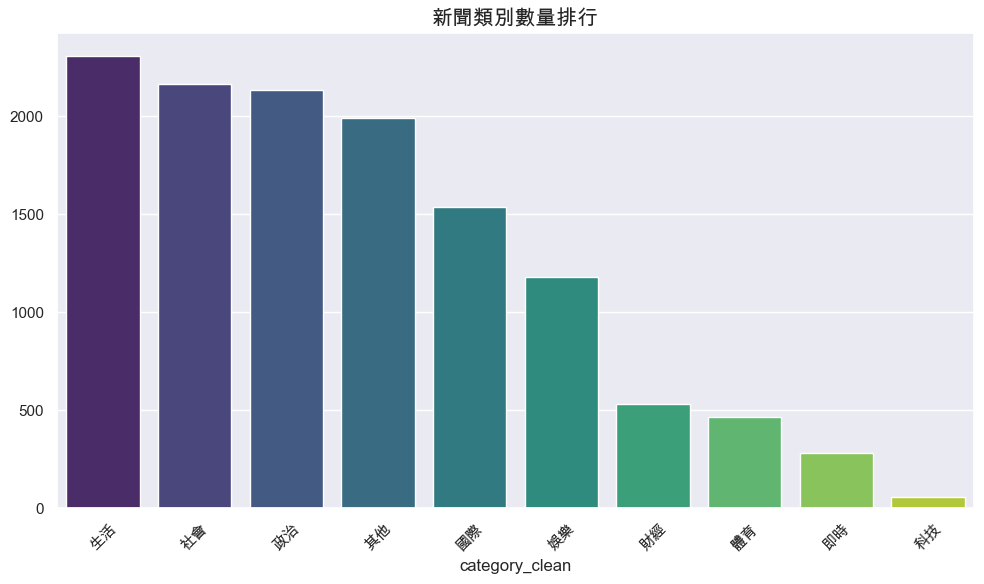

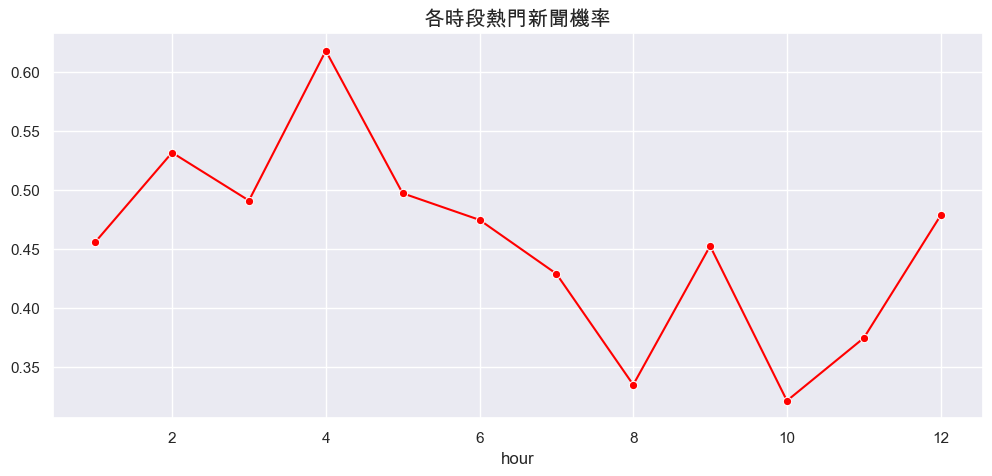

☁️ 生成文字雲 (熱門 & 一般)...


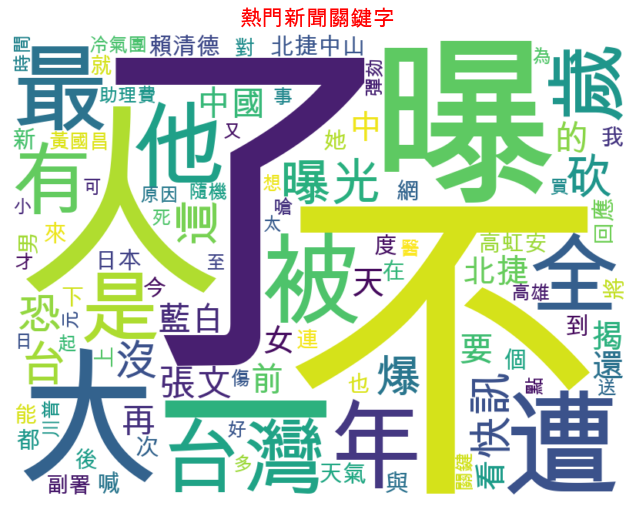

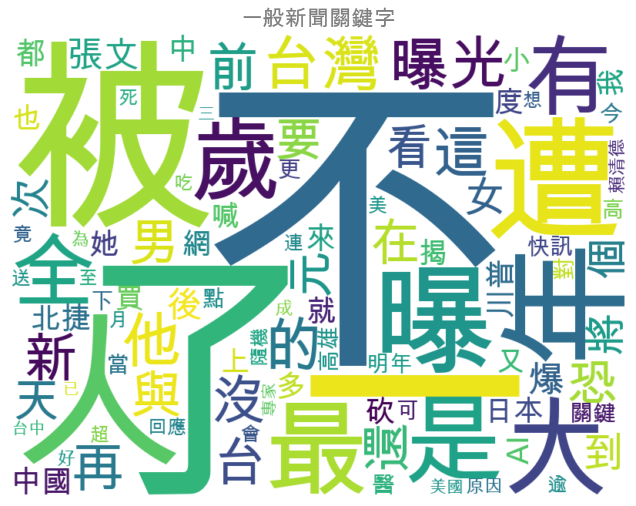


💾 正在儲存最終資料: News_Data_cleaned_2.csv
✅ 全部完成！
   最終欄位 (13欄): ['label', 'category_clean', 'title_clean', 'content_clean', 'title_len', 'punct_count', 'has_digit', 'hour', 'is_prime_time', 'is_work_hour', 'is_weekend', 'viral_latency_hours', 'is_instant_viral']


In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from datetime import datetime
from wordcloud import WordCloud
import matplotlib.font_manager as fm

# 匯入 Worker
try:
    import pipeline_worker_2
except ImportError:
    print("❌ 找不到 pipeline_worker_2.py")

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_FILE = 'News_Data.csv'           # 原始爬蟲資料
OUTPUT_FILE = 'News_Data_cleaned_2.csv' # 最終完整版訓練資料

# ==========================================
# 🛠️ 自動字體修復
# ==========================================
def get_chinese_font():
    font_names = ['Arial Unicode MS', 'PingFang TC', 'Heiti TC', 'Microsoft JhengHei', 'SimHei', 'Noto Sans CJK TC']
    system_fonts = set(f.name for f in fm.fontManager.ttflist)
    detected_font = next((f for f in font_names if f in system_fonts), None)
    
    font_path = None
    common_paths = [
        '/System/Library/Fonts/Supplemental/Arial Unicode.ttf', 
        '/System/Library/Fonts/PingFang.ttc', 
        'C:/Windows/Fonts/msjh.ttc', 
        'C:/Windows/Fonts/simhei.ttf', 
        '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc'
    ]
    for path in common_paths:
        if os.path.exists(path):
            font_path = path
            break
            
    return detected_font, font_path

mpl_font, wc_font_path = get_chinese_font()
if mpl_font:
    plt.rcParams['font.sans-serif'] = [mpl_font]
    plt.rcParams['axes.unicode_minus'] = False
    sns.set(font=mpl_font)
else:
    plt.rcParams['font.sans-serif'] = ['sans-serif']

# ==========================================
# 🕒 時間特徵處理
# ==========================================
def process_time_features(df):
    print("   -> 正在提取時間與升級速度特徵...")
    df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
    if 'fetch_time' in df.columns:
        df['fetch_time'] = pd.to_datetime(df['fetch_time'], errors='coerce')
    
    df = df.dropna(subset=['publish_time'])
    
    # 基礎特徵
    df['hour'] = df['publish_time'].dt.hour
    # df['weekday'] = df['publish_time'].dt.dayofweek # 移除 weekday，改用 is_weekend
    
    df['is_prime_time'] = df['hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)
    df['is_work_hour'] = df['hour'].apply(lambda x: 1 if 9 <= x <= 17 else 0)
    df['is_weekend'] = df['publish_time'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
    
    # 升級速度 (Velocity)
    if 'fetch_time' in df.columns:
        df['time_gap_seconds'] = (df['fetch_time'] - df['publish_time']).dt.total_seconds()
        df['time_gap_seconds'] = df['time_gap_seconds'].apply(lambda x: x if x >= 0 else 0)
        df['viral_latency_hours'] = df['time_gap_seconds'] / 3600.0
        df['is_instant_viral'] = df['viral_latency_hours'].apply(lambda x: 1 if x < 1.0 else 0)
    else:
        df['viral_latency_hours'] = 0
        df['is_instant_viral'] = 0
        
    return df

# ==========================================
# 🚀 主程式
# ==========================================
if __name__ == "__main__":
    print(f"🚀 [Step 1] 讀取原始資料: {INPUT_FILE}")
    try:
        df = pd.read_csv(INPUT_FILE)
    except:
        df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')

    # 1. 多核心清洗
    print(f"🚀 [Step 2] 啟動多核心處理...")
    num_cores = multiprocessing.cpu_count()
    chunks = np.array_split(df, num_cores)
    
    df_list = []
    with ProcessPoolExecutor(max_workers=num_cores) as executor:
        results = executor.map(pipeline_worker_2.worker_process_chunk, chunks)
        for res in results: df_list.append(res)
    df_clean = pd.concat(df_list)
    
    # 2. 時間特徵
    df_final = process_time_features(df_clean)
    
    # 3. 確保 Label
    if 'label' not in df_final.columns and 'views' in df_final.columns:
        print("   -> 自動產生 label (Top 20%)")
        threshold = df_final['views'].quantile(0.8)
        df_final['label'] = (df_final['views'] >= threshold).astype(int)
    
    # ==========================================
    # 📊 EDA 視覺化
    # ==========================================
    print("\n📊 執行視覺化分析 (圖片將存檔)...")
    
    # (1) 類別排行
    plt.figure(figsize=(10, 6))
    cat_counts = df_final['category_clean'].value_counts()
    sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')
    plt.title('新聞類別數量排行', fontsize=15)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('eda_category_rank.png', dpi=300)
    plt.show()
    
    # (2) 時間趨勢
    plt.figure(figsize=(12, 5))
    hourly_hot_ratio = df_final.groupby('hour')['label'].mean()
    sns.lineplot(x=hourly_hot_ratio.index, y=hourly_hot_ratio.values, marker='o', color='red')
    plt.title('各時段熱門新聞機率', fontsize=15)
    plt.grid(True)
    plt.savefig('eda_hourly_trend.png', dpi=300)
    plt.show()
    
    # (3) 文字雲 (熱門 vs 一般)
    if wc_font_path and 'tokens' in df_final.columns:
        print("☁️ 生成文字雲 (熱門 & 一般)...")
        wc_cfg = {'font_path': wc_font_path, 'width': 800, 'height': 600, 'background_color': 'white', 'max_words': 100, 'collocations': False}
        
        try:
            # 熱門 (Label 1)
            l1_text = " ".join(df_final[df_final['label']==1]['tokens'].astype(str))
            if len(l1_text.strip()) > 0:
                wc = WordCloud(**wc_cfg).generate(l1_text)
                plt.figure(figsize=(8, 6))
                plt.imshow(wc, interpolation="bilinear")
                plt.title("熱門新聞關鍵字", fontsize=16, color='red')
                plt.axis('off')
                plt.savefig('eda_wordcloud_L1.png', dpi=300)
                plt.show()

            # 一般 (Label 0)
            l0_text = " ".join(df_final[df_final['label']==0]['tokens'].astype(str))
            if len(l0_text.strip()) > 0:
                wc = WordCloud(**wc_cfg).generate(l0_text)
                plt.figure(figsize=(8, 6))
                plt.imshow(wc, interpolation="bilinear")
                plt.title("一般新聞關鍵字", fontsize=16, color='gray')
                plt.axis('off')
                plt.savefig('eda_wordcloud_L0.png', dpi=300)
                plt.show()
                
        except Exception as e:
            print(f"⚠️ 文字雲錯誤: {e}")

    # ==========================================
    # 💾 存檔 (保留 Content，移除 Weekday)
    # ==========================================
    cols_model_needs = [
        'label',             # Target
        'category_clean',    # Info
        'title_clean',       # Feature: Text (BERT)
        'content_clean',     # Feature: Text (Longformer/Info) - 已加回
        'title_len',         # Feature: Stat
        'punct_count',       # Feature: Stat
        'has_digit',         # Feature: Stat
        'hour',              # Feature: Time (重要)
        # 'weekday',         # 移除 (不重要)
        'is_prime_time',     # Feature: Time (重要)
        'is_work_hour',      # Feature: Time (重要)
        'is_weekend',        # Feature: Time (重要)
        'viral_latency_hours', # Feature: Velocity (重要)
        'is_instant_viral'   # Feature: Velocity (重要)
    ]
    
    final_cols = [c for c in cols_model_needs if c in df_final.columns]
    df_save = df_final[final_cols].copy()
    
    print(f"\n💾 正在儲存最終資料: {OUTPUT_FILE}")
    df_save.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
    
    print(f"✅ 全部完成！")
    print(f"   最終欄位 ({len(final_cols)}欄): {final_cols}")